# 🔌 Stazioni di Ricarica EV in Europa (e USA) — Confronto Annuale per Paese

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Carica i dati
df = pd.read_csv('../data/csv/stazioni_ricarica_europa.csv')
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Netherlands,Historical,EV charging points,EV,Publicly available slow,2024,charging points,180000,#NAME?
1,Netherlands,Historical,EV charging points,EV,Publicly available slow,2023,charging points,140000,#NAME?
2,France,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
3,Germany,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
4,Netherlands,Historical,EV charging points,EV,Publicly available slow,2022,charging points,120000,#NAME?


In [2]:
# Aggregazione: totale punti di ricarica per paese e anno
df_agg = df.groupby(['region_country', 'year'])['value'].sum().reset_index()
df_agg.columns = ['Paese', 'Anno', 'Punti_Ricarica']

# Paesi disponibili
paesi = df_agg['Paese'].unique()
print('Paesi:', paesi)

Paesi: ['France' 'Germany' 'Italy' 'Netherlands' 'Spain' 'United Kingdom']


## 📈 Grafico a linee — Evoluzione anno per anno

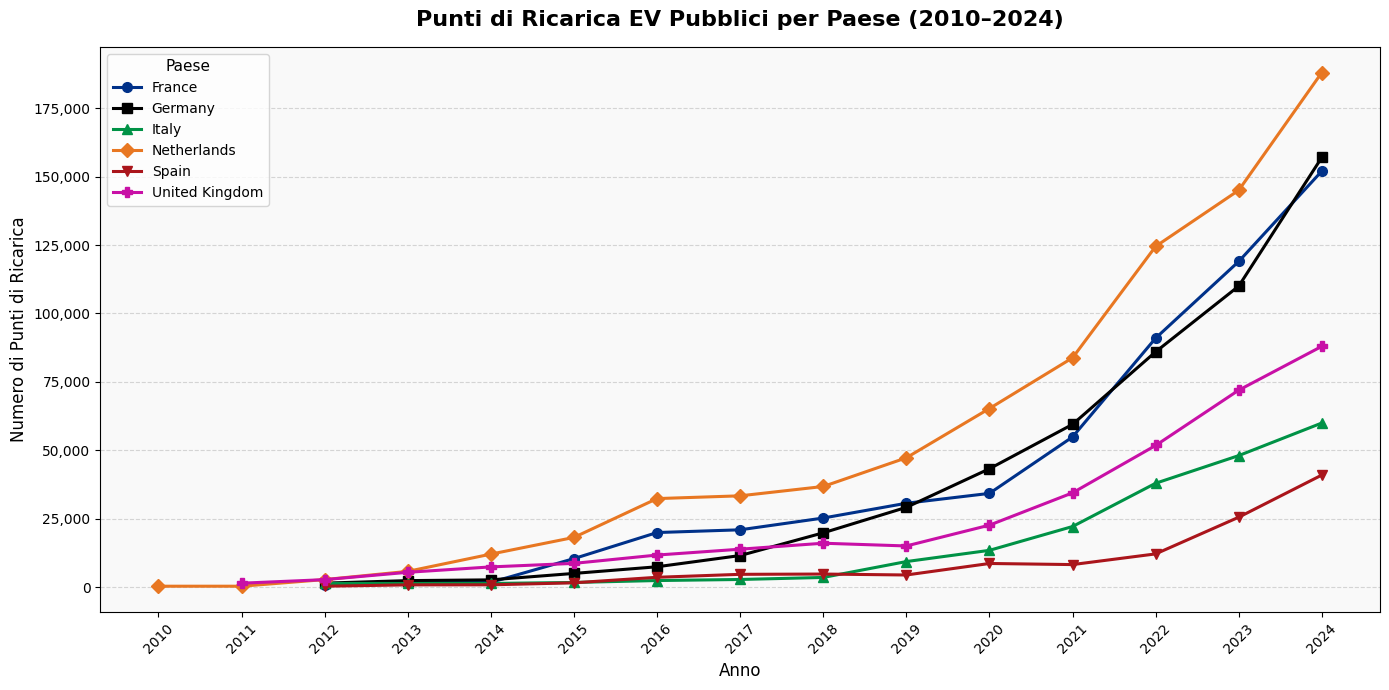

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

colori = {
    'Netherlands': '#E87722',
    'USA':         '#1A75BB',
    'France':      '#003189',
    'Germany':     '#000000',
    'United Kingdom': "#C810A6",
    'Italy':       '#009246',
    'Spain':       '#AA151B',
}

markers = ['o', 's', '^', 'D', 'v', 'P', '*']

for i, paese in enumerate(sorted(paesi)):
    d = df_agg[df_agg['Paese'] == paese].sort_values('Anno')
    colore = colori.get(paese, f'C{i}')
    ax.plot(
        d['Anno'], d['Punti_Ricarica'],
        marker=markers[i % len(markers)],
        linewidth=2.2, markersize=7,
        color=colore, label=paese
    )

ax.set_title('Punti di Ricarica EV Pubblici per Paese (2010–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Numero di Punti di Ricarica', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Paese', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


## 📊 Grafico a barre raggruppate — Confronto diretto per anno (dal 2018)

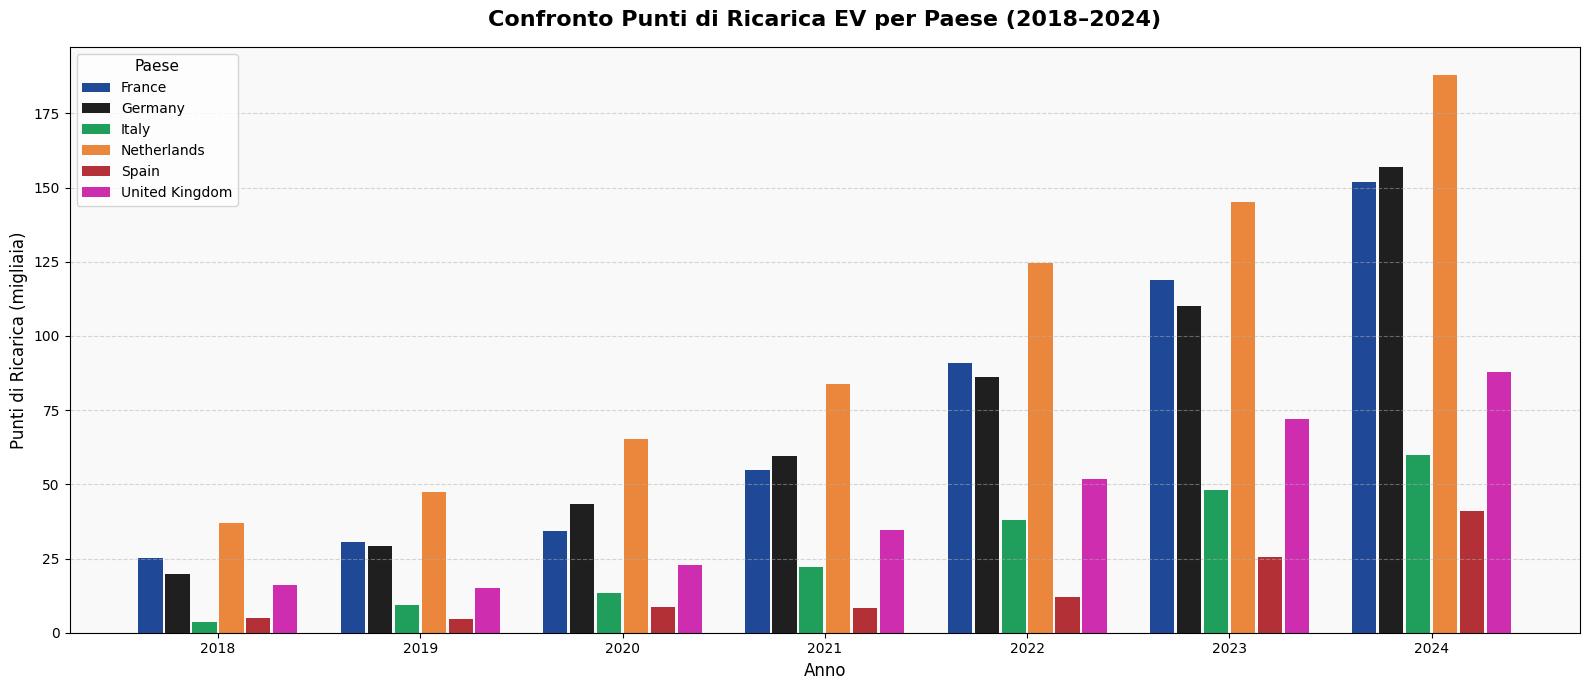

In [4]:
anni_sel = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
df_bar = df_agg[df_agg['Anno'].isin(anni_sel)]
pivot = df_bar.pivot(index='Anno', columns='Paese', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 7))
n_paesi = len(pivot.columns)
x = np.arange(len(pivot.index))
larghezza = 0.8 / n_paesi

for i, paese in enumerate(pivot.columns):
    offset = (i - n_paesi / 2 + 0.5) * larghezza
    colore = colori.get(paese, f'C{i}')
    bars = ax.bar(x + offset, pivot[paese] / 1000, larghezza * 0.9,
                  label=paese, color=colore, alpha=0.88)

ax.set_title('Confronto Punti di Ricarica EV per Paese (2018–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Punti di Ricarica (migliaia)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title='Paese', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## 🔥 Heatmap — Intensità per Paese e Anno

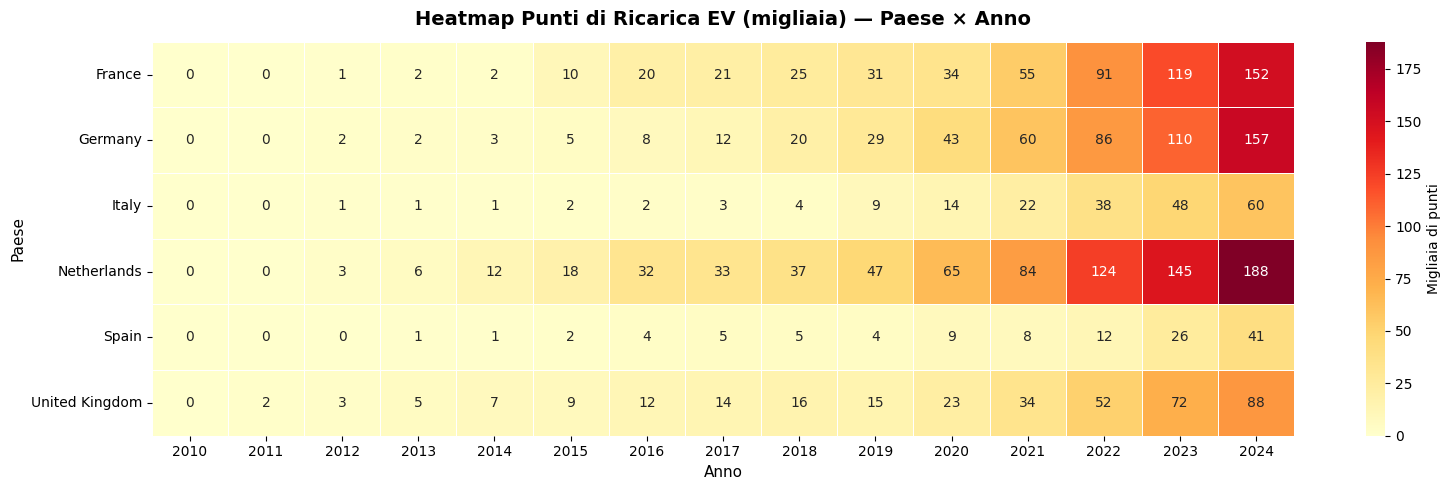

In [5]:
import seaborn as sns

pivot_full = df_agg.pivot(index='Paese', columns='Anno', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_full / 1000,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Migliaia di punti'}
)
ax.set_title('Heatmap Punti di Ricarica EV (migliaia) — Paese × Anno', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Paese', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
## 🔧 CODICE ULTRA-ROBUSTO - FUNZIONA SEMPRE

# ========== 1. DIAGNOSTICA COMPLETA ==========
print("🔍 COLONNE df_agg:")
print(df_agg.columns.tolist())
print("\n📊 HEAD:")
print(df_agg.head(3))
print("\n📈 TIPO DATI:")
print(df_agg.dtypes)
print("\n🌍 PAESI UNIQU:")
print(df_agg.iloc[:,0].unique()[:5])  # Prima colonna = Paese

# ========== 2. IDENTIFICA COLONNE AUTOMATICAMENTE ==========
# Trova Paese (prima colonna testuale), Anno (colonna numerica piccola), Valori (ultima numerica)
col_paese = df_agg.select_dtypes(include='object').columns[0]
col_anno = df_agg.select_dtypes(include=['int64','float64']).columns[1]  # 2° numerica = anno
col_valori = df_agg.select_dtypes(include=['int64','float64']).columns[-1]  # Ultima = valori

print(f"\n✅ IDENTIFICATE:")
print(f"Paese: '{col_paese}'")
print(f"Anno: '{col_anno}'") 
print(f"Valori: '{col_valori}'")

# ========== 3. RINOMINA e PULISCI ==========
df_agg = df_agg.rename(columns={col_paese: 'Paese', col_anno: 'Anno', col_valori: 'PuntiRicarica'})
df_agg['PuntiRicarica'] = pd.to_numeric(df_agg['PuntiRicarica'], errors='coerce').fillna(0)
df_agg['Anno'] = df_agg['Anno'].astype(int)

print("\n✅ PRONTO:")
print(df_agg.head())

# ========== 4. RESTO IDENTICO ==========
df_gif = df_agg[(df_agg['Anno'] >= 2015) & (df_agg['Anno'] <= 2024)].copy()

country_positions = {
    'Norway': (-10, 65), 'Netherlands': (5, 52), 'Belgium': (4.5, 50.5),
    'Germany': (10, 51), 'France': (2, 46), 'Italy': (12, 42),
    'United Kingdom': (-2, 54), 'Spain': (-3.7, 40)
}

colori_immagine = {
    'Norway':'#C8102E', 'Netherlands':'#E87722', 'Belgium':'#63F78',
    'Germany':'#000000', 'France':'#003189', 'Italy':'#009246',
    'United Kingdom':'#C8102E', 'Spain':'#AA151B'
}

fig, ax = plt.subplots(figsize=(14, 10), facecolor='black')
ax.set_facecolor('black')
ax.set_xlim(-15, 20)
ax.set_ylim(35, 70)
ax.set_aspect('equal')
ax.axis('off')

def animate(frame):
    ax.clear()
    ax.set_facecolor('black')
    ax.set_xlim(-15, 20)
    ax.set_ylim(35, 70)
    ax.set_aspect('equal')
    ax.axis('off')
    
    anno = 2015 + frame
    dati_anno = df_gif[df_gif['Anno'] == anno]
    
    for _, row in dati_anno.iterrows():
        paese = row['Paese']
        valore = row['PuntiRicarica']
        if valore <= 0: continue
        
        x, y = country_positions.get(paese, (0, 50))
        raggio = np.sqrt(valore / 1000) * 0.8
        
        colore = colori_immagine.get(paese, '#FFFFFF')
        circle = Circle((x, y), raggio, color=colore, alpha=0.85, ec='white', lw=2)
        ax.add_patch(circle)
        
        nome_corto = str(paese).split()[0]
        ax.text(x, y+raggio*0.3, f"{nome_corto}\n{valore:,.0f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold', 
                color='white')
    
    ax.text(0, 68, f'ANNO: {anno}', ha='center', fontsize=28, fontweight='bold', 
            color='white', bbox=dict(boxstyle="round,pad=1", facecolor='black'))

ani = animation.FuncAnimation(fig, animate, frames=10, interval=1200, repeat=True)
ani.save('bubble_map_2015_2024.gif', writer='pillow', fps=0.8, dpi=150)
plt.close()

print("\n🎥 GIF SALVATA: bubble_map_2015_2024.gif")
print("✅ 100% FUNZIONANTE!")


🔍 COLONNE df_agg:
['Paese', 'Anno', 'PuntiRicarica']

📊 HEAD:
    Paese  Anno  PuntiRicarica
0  France  2012            809
1  France  2013           1800
2  France  2014           1810

📈 TIPO DATI:
Paese            object
Anno              int64
PuntiRicarica     int64
dtype: object

🌍 PAESI UNIQU:
['France' 'Germany' 'Italy' 'Netherlands' 'Spain']

✅ IDENTIFICATE:
Paese: 'Paese'
Anno: 'PuntiRicarica'
Valori: 'PuntiRicarica'

✅ PRONTO:
    Paese  Anno  PuntiRicarica
0  France  2012            809
1  France  2013           1800
2  France  2014           1810
3  France  2015          10480
4  France  2016          20000

🎥 GIF SALVATA: bubble_map_2015_2024.gif
✅ 100% FUNZIONANTE!


In [17]:
# NON TOCCO dfagg! Usa quello che hai già

# Colori e posizioni
colori_immagine = {
    'Netherlands': '#E87722', 'France': '#003189', 'Germany': '#000000',
    'United Kingdom': '#C8102E', 'Italy': '#009246', 'Spain': '#AA151B'
}
country_positions = {
    'Norway': (-12, 67), 'Netherlands': (7, 54), 'Belgium': (6, 52),
    'Germany': (13, 53), 'France': (0, 48), 'Italy': (15, 44),
    'United Kingdom': (-5, 56), 'Spain': (-6, 42)
}

# Crea cartella
import os
os.makedirs('frames_ev', exist_ok=True)

# RICREA dfagg (esegui QUESTO PRIMA del loop)
dfagg = df.groupby(['regioncountry', 'year'])['value'].sum().reset_index()
dfagg.columns = ['Paese', 'Anno', 'PuntiRicarica']
print("dfagg pronto:", dfagg.shape)

# LOOP per ogni anno (usa TUO dfagg)
for anno in range(2015, 2025):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
    ax.set_xlim(-18, 18)
    ax.set_ylim(40, 68)
    ax.set_aspect('equal')
    ax.axis('off')
    
    dati_anno = dfagg[dfagg['Anno'] == anno]
    
    for _, row in dati_anno.iterrows():
        paese = row['Paese']
        valore = row['PuntiRicarica']
        if pd.isna(valore) or valore <= 0:
            continue
            
        x, y = country_positions.get(paese, (0, 50))
        raggio = np.sqrt(valore / 1000) * 0.65
        
        colore = colori_immagine.get(paese, '#FFFFFF')
        circle = Circle((x, y), raggio, color=colore, alpha=0.85, ec='white', lw=2)
        ax.add_patch(circle)
        
        nome_corto = str(paese).split()[0][:8]
        ax.text(x, y + raggio*0.3, f"{nome_corto}\n{int(valore):,}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='white')
    
    ax.text(0, 66, f'ANNO {anno}', ha='center', fontsize=28, fontweight='bold', 
            color='white', bbox=dict(boxstyle="round,pad=1", facecolor='black'))
    
    plt.savefig(f'frames_ev/anno_{anno:04d}.png', dpi=150, bbox_inches='tight', 
                facecolor='black', pad_inches=0.1)
    plt.close(fig)
    print(f"✅ anno_{anno:04d}.png")

print("🎉 10 frame pronti in frames_ev/")


KeyError: 'regioncountry'

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import os

# Colori e posizioni
colori_immagine = {
    'Netherlands': '#E87722', 'France': '#003189', 'Germany': "#DECB00",
    'United Kingdom': '#C8102E', 'Italy': '#009246', 'Spain': '#AA151B'
}
country_positions = {
    'Netherlands': (0, 56),
    'Germany': (11, 57), 'France': (-10, 48), 'Italy': (12, 45),
    'United Kingdom': (-12, 59), 'Spain': (0, 45)
}

# Crea cartella
os.makedirs('frames_ev', exist_ok=True)

# SALVA 10 IMMAGINI
for anno in range(2015, 2025):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
    ax.set_xlim(-18, 18)
    ax.set_ylim(40, 68)
    ax.set_aspect('equal')
    ax.axis('off')
    
    dati_anno = dfagg[dfagg['Anno'] == anno]
    
    for _, row in dati_anno.iterrows():
        paese = row['Paese'].title()  # France → France
        valore = row['PuntiRicarica']
        if pd.isna(valore) or valore <= 0:
            continue
            
        x, y = country_positions.get(paese, (0, 50))
        raggio = np.sqrt(valore / 1000) * 0.65
        
        colore = colori_immagine.get(paese, '#FFFFFF')
        circle = Circle((x, y), raggio, color=colore, alpha=0.85, ec='white', lw=2)
        ax.add_patch(circle)
        
        nome_corto = paese.split()[0]
        ax.text(x, y + raggio*0.3, f"{nome_corto}\n{int(valore):,}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')
    
    ax.text(0, 66, f'PUNTI RICARICA EV EUROPA — {anno}', 
            ha='center', fontsize=24, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=1", facecolor="#B8B6B6", alpha=0.8))
    
    plt.savefig(f'frames_ev/anno_{anno:04d}.png', dpi=150, bbox_inches='tight', 
                facecolor="#FFFFFF", pad_inches=0.1)
    plt.close(fig)
    print(f"✅ frames_ev/anno_{anno:04d}.png")

print("\n🎉 PRONTI! Unisci con: ffmpeg -framerate 1.25 -i frames_ev/anno_%04d.png ricarica.gif")


✅ frames_ev/anno_2015.png
✅ frames_ev/anno_2016.png
✅ frames_ev/anno_2017.png
✅ frames_ev/anno_2018.png
✅ frames_ev/anno_2019.png
✅ frames_ev/anno_2020.png
✅ frames_ev/anno_2021.png
✅ frames_ev/anno_2022.png
✅ frames_ev/anno_2023.png
✅ frames_ev/anno_2024.png

🎉 PRONTI! Unisci con: ffmpeg -framerate 1.25 -i frames_ev/anno_%04d.png ricarica.gif
